In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# upload file di Colab dulu
from google.colab import files
uploaded = files.upload()

Saving coffee_sales_correlation_dataset.csv to coffee_sales_correlation_dataset.csv


In [ ]:
# load dataset
df = pd.read_csv('coffee_sales_correlation_dataset.csv')

# lihat isi data
df.head()

,Day,Temperature_C,Rainfall_mm,Advertising_Budget,Coffee_Sales
0,1,32,0,200,180
1,2,31,0,180,170
2,3,30,1,160,165
3,4,29,2,140,150
4,5,28,4,120,140


In [ ]:
# hitung korelasi Pearson
corr_suhu = df['Temperature_C'].corr(df['Coffee_Sales'])
corr_hujan = df['Rainfall_mm'].corr(df['Coffee_Sales'])
corr_promosi = df['Advertising_Budget'].corr(df['Coffee_Sales'])

print("Korelasi Suhu vs Penjualan:", corr_suhu)
print("Korelasi Hujan vs Penjualan:", corr_hujan)
print("Korelasi Promosi vs Penjualan:", corr_promosi)

Korelasi Suhu vs Penjualan: 0.9920822777687766
Korelasi Hujan vs Penjualan: -0.9607545153301694
Korelasi Promosi vs Penjualan: 0.9764520345884075


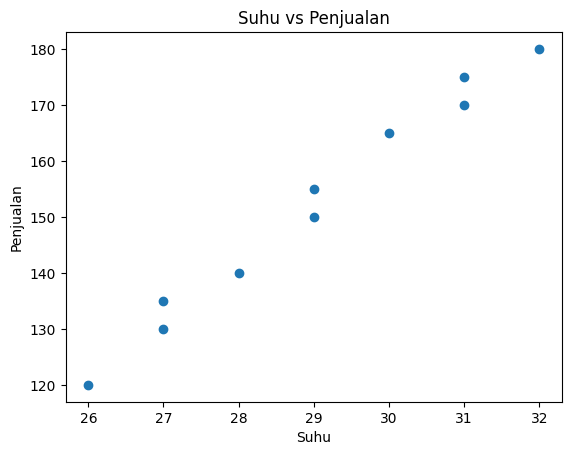

In [ ]:
plt.figure()
plt.scatter(df['Temperature_C'], df['Coffee_Sales'])
plt.xlabel("Suhu")
plt.ylabel("Penjualan")
plt.title("Suhu vs Penjualan")
plt.show()

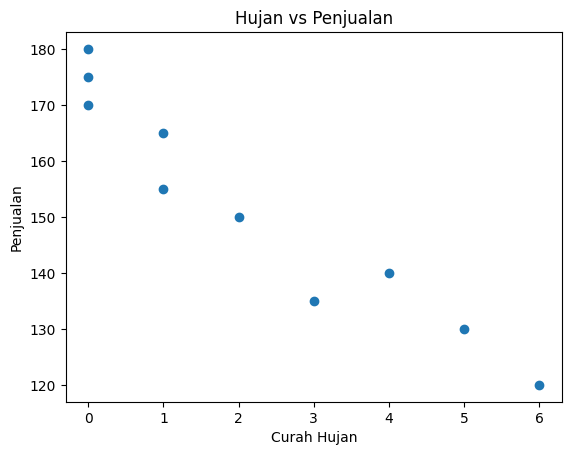

In [ ]:
plt.figure()
plt.scatter(df['Rainfall_mm'], df['Coffee_Sales'])
plt.xlabel("Curah Hujan")
plt.ylabel("Penjualan")
plt.title("Hujan vs Penjualan")
plt.show()

In [ ]:
from scipy import stats

# residual suhu setelah dikontrol hujan
res_suhu = stats.linregress(df['Rainfall_mm'], df['Temperature_C'])
pred_suhu = res_suhu.intercept + res_suhu.slope * df['Rainfall_mm']
residual_suhu = df['Temperature_C'] - pred_suhu

# residual penjualan setelah dikontrol hujan
res_penjualan = stats.linregress(df['Rainfall_mm'], df['Coffee_Sales'])
pred_penjualan = res_penjualan.intercept + res_penjualan.slope * df['Rainfall_mm']
residual_penjualan = df['Coffee_Sales'] - pred_penjualan

# korelasi partial
partial_corr = np.corrcoef(residual_suhu, residual_penjualan)[0,1]

print("Partial Correlation (Suhu vs Penjualan | Hujan):", partial_corr)

Partial Correlation (Suhu vs Penjualan | Hujan): 0.9561369949481976


In [ ]:
import statsmodels.api as sm

X = df[['Temperature_C','Rainfall_mm','Advertising_Budget']]
y = df['Coffee_Sales']

# tambah konstanta
X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           Coffee_Sales   R-squared:                       0.994
Model:                            OLS   Adj. R-squared:                  0.991
Method:                 Least Squares   F-statistic:                     339.2
Date:                Wed, 25 Mar 2026   Prob (F-statistic):           4.40e-07
Time:                        05:35:44   Log-Likelihood:                -18.141
No. Observations:                  10   AIC:                             44.28
Df Residuals:                       6   BIC:                             45.49
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  2.6676     79

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


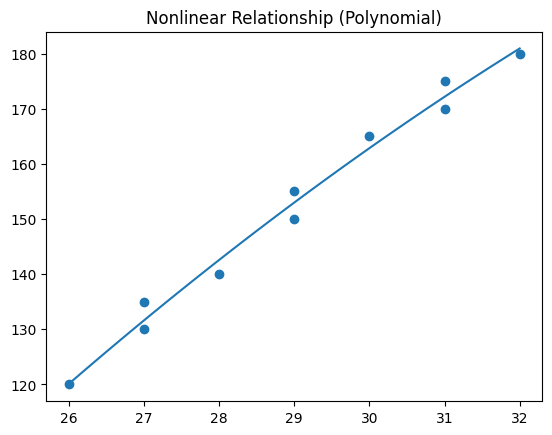

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(df[['Temperature_C']])

model_poly = LinearRegression()
model_poly.fit(X_poly, df['Coffee_Sales'])

# plot
plt.figure()
plt.scatter(df['Temperature_C'], df['Coffee_Sales'])

x_range = np.linspace(df['Temperature_C'].min(), df['Temperature_C'].max(), 100)
x_range_poly = poly.transform(x_range.reshape(-1,1))
y_pred = model_poly.predict(x_range_poly)

plt.plot(x_range, y_pred)
plt.title("Nonlinear Relationship (Polynomial)")
plt.show()